### 3 Class Image Classification using Transfer Learning

#### Problem Statement
I've and train a **3-class image classification model** using **Transfer Learning** on the provided dataset.

In [1]:
import os, warnings, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets, models
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
elif torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

Device : mps
PyTorch: 2.10.0


In [2]:
import os
os.getcwd()

'/Users/suchibrata/Documents/SP_Assignment/2'

In [3]:
# Configuration
DATA_DIR      = 'data'          # path to unzipped data folder
IMG_SIZE      = 224             # MobileNetV2 expects 224x224
BATCH_SIZE    = 32
NUM_CLASSES   = 3
EPOCHS_FROZEN = 5               # Phase 1: train head only  (backbone frozen)
EPOCHS_FINETUNE = 10            # Phase 2: fine-tune top layers of backbone
LR_HEAD       = 1e-3            # learning rate for classification head
LR_FINETUNE   = 1e-4            # learning rate for fine-tuning
VAL_SPLIT     = 0.2             # 80 % train, 20 % val
CLASS_NAMES   = ['CS', 'D', 'DD']   # alphabetical order used by ImageFolder


In [4]:
# Data Transformation
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),   # L → RGB
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats
                         std =[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

print("Transforms defined.")


Transforms defined.


In [5]:
# Dataset & DataLoader
full_dataset = datasets.ImageFolder(root=DATA_DIR)
CLASS_NAMES  = full_dataset.classes
print(f"Classes : {CLASS_NAMES}")
print(f"Total   : {len(full_dataset)} images")

from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

labels = [s[1] for s in full_dataset.samples]
train_idx, val_idx = train_test_split(
    range(len(full_dataset)), test_size=VAL_SPLIT,
    stratify=labels, random_state=SEED
)

class SubsetWithTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]   # img is PIL Image (no base transform)
        if self.transform:
            img = self.transform(img)
        return img, label

train_subset = Subset(full_dataset, train_idx)
val_subset   = Subset(full_dataset, val_idx)

train_ds = SubsetWithTransform(train_subset, train_transforms)
val_ds   = SubsetWithTransform(val_subset,   val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"Train   : {len(train_ds)} | Val: {len(val_ds)}")

Classes : ['CS', 'D', 'DD']
Total   : 630 images
Train   : 504 | Val: 126


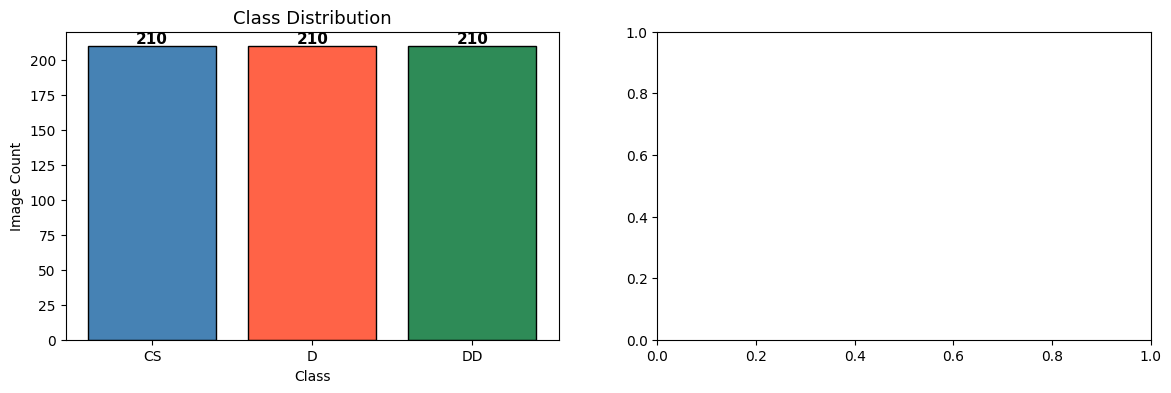

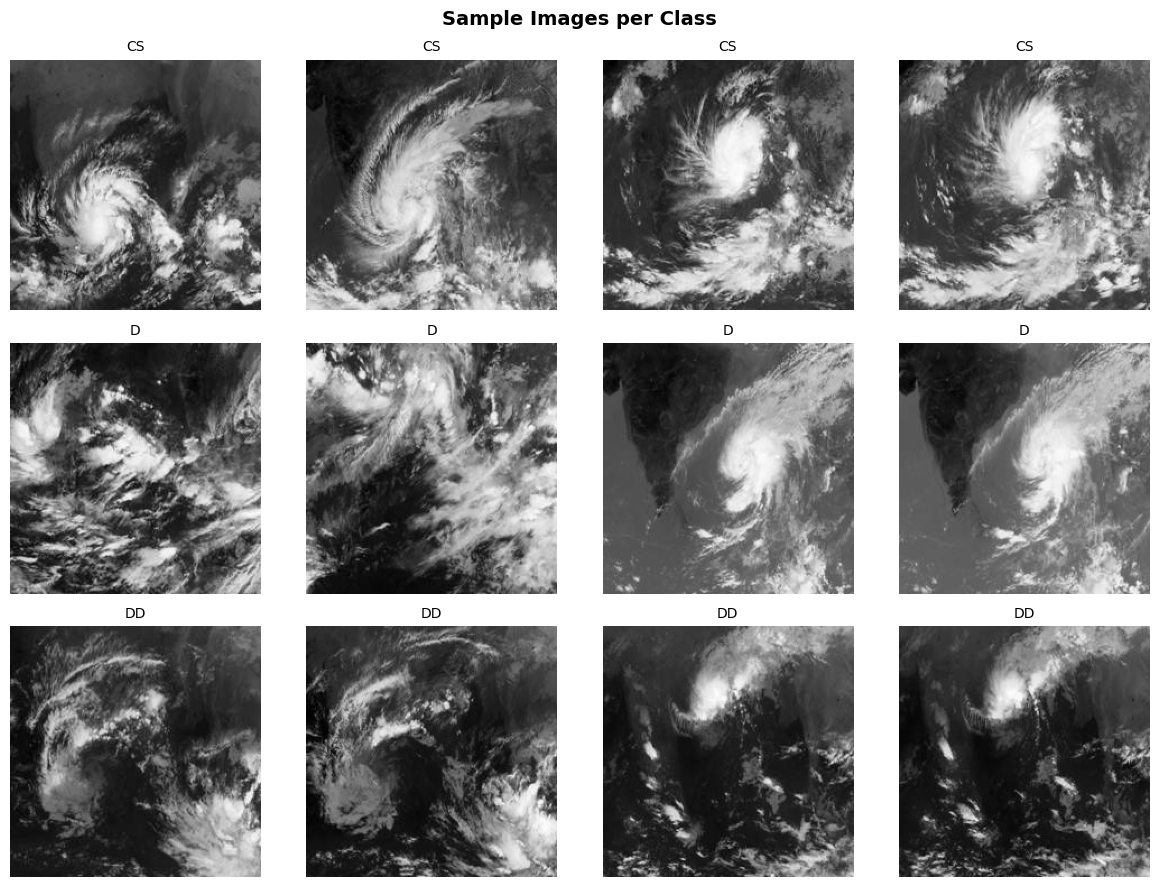

<Figure size 640x480 with 0 Axes>

Dataset is perfectly balanced — no resampling needed.


In [6]:
#EDA
from collections import Counter

all_labels = [s[1] for s in full_dataset.samples]
counts = Counter(all_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class distribution bar chart
axes[0].bar([CLASS_NAMES[i] for i in sorted(counts)],
            [counts[i] for i in sorted(counts)],
            color=['steelblue','tomato','seagreen'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Image Count')
for i, (k, v) in enumerate(sorted(counts.items())):
    axes[0].text(i, v+2, str(v), ha='center', fontsize=11, fontweight='bold')

# Sample images grid
from PIL import Image
sample_paths = {c: [] for c in CLASS_NAMES}
for path, lbl in full_dataset.samples:
    if len(sample_paths[CLASS_NAMES[lbl]]) < 4:
        sample_paths[CLASS_NAMES[lbl]].append(path)

grid_fig, grid_axes = plt.subplots(3, 4, figsize=(12, 9))
for r, cls in enumerate(CLASS_NAMES):
    for c, p in enumerate(sample_paths[cls]):
        img = Image.open(p)
        grid_axes[r][c].imshow(img, cmap='gray')
        grid_axes[r][c].set_title(f'{cls}', fontsize=10)
        grid_axes[r][c].axis('off')
grid_fig.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

axes[1].axis('off')
plt.tight_layout(); plt.show()
print("Dataset is perfectly balanced — no resampling needed.")

In [7]:
# MobileNetV2 with Custom Head

def build_model(num_classes=NUM_CLASSES):
    backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    # ── Freeze all backbone parameters ───────────────────────────────────────
    for param in backbone.parameters():
        param.requires_grad = False

    # ── Replace classifier head ───────────────────────────────────────────────
    in_features = backbone.classifier[1].in_features
    backbone.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes)
    )
    return backbone

model = build_model()
model = model.to(DEVICE)

# Quick parameter count
total   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}  ({100*trainable/total:.1f} %)")
print(model.classifier)


Total params    : 2,552,579
Trainable params: 328,707  (12.9 %)
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=3, bias=True)
)


In [8]:
# Training & Evaluation Helpers
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct  += (preds == labels).sum().item()
        total    += imgs.size(0)
    return running_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct  += (preds == labels).sum().item()
            total    += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return running_loss / total, correct / total, all_preds, all_labels


def run_training(model, train_loader, val_loader, epochs, lr, phase_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc, best_state = 0.0, None

    print(f"\n{'='*55}")
    print(f"  {phase_name}")
    print(f"{'='*55}")
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>8}")
    print(f"{'-'*55}")

    for epoch in range(1, epochs + 1):
        t_loss, t_acc = train_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc, _, _ = eval_epoch(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(t_loss); history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc);   history['val_acc'].append(v_acc)

        marker = ' ✓' if v_acc > best_val_acc else ''
        print(f"{epoch:>6} | {t_loss:>10.4f} | {t_acc:>9.4f} | {v_loss:>8.4f} | {v_acc:>8.4f}{marker}")

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    print(f"\nBest Val Accuracy: {best_val_acc:.4f}")
    return history, best_val_acc

print("Helper functions defined.")


Helper functions defined.


In [9]:
# Train Classification Head (Backbone Frozen)
history_phase1, best_acc_p1 = run_training(
    model, train_loader, val_loader,
    epochs=EPOCHS_FROZEN, lr=LR_HEAD,
    phase_name="Phase 1 — Head Training (Backbone Frozen)"
)



  Phase 1 — Head Training (Backbone Frozen)
 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc
-------------------------------------------------------
     1 |     1.1155 |    0.3909 |   1.0632 |   0.4048 ✓
     2 |     1.0595 |    0.4405 |   1.1368 |   0.3889
     3 |     1.0684 |    0.4504 |   1.0453 |   0.4524 ✓
     4 |     1.0318 |    0.4544 |   1.0421 |   0.4683 ✓
     5 |     1.0162 |    0.4802 |   1.0008 |   0.5397 ✓

Best Val Accuracy: 0.5397


In [10]:
# Fine-Tune Top Backbone Layers
UNFREEZE_FROM = -30   # last ~30 parameter groups

for param in list(model.parameters())[UNFREEZE_FROM:]:
    param.requires_grad = True

trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params in Phase 2: {trainable_p2:,}")

history_phase2, best_acc_p2 = run_training(
    model, train_loader, val_loader,
    epochs=EPOCHS_FINETUNE, lr=LR_FINETUNE,
    phase_name="Phase 2 — Fine-Tuning (Top Backbone Layers)"
)


Trainable params in Phase 2: 1,690,627

  Phase 2 — Fine-Tuning (Top Backbone Layers)
 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc
-------------------------------------------------------
     1 |     1.0012 |    0.5060 |   0.9698 |   0.5873 ✓
     2 |     0.9188 |    0.5754 |   0.9639 |   0.5556
     3 |     0.8413 |    0.6111 |   0.9947 |   0.5635
     4 |     0.8469 |    0.6290 |   0.9190 |   0.5873
     5 |     0.7891 |    0.6468 |   0.8836 |   0.6429 ✓
     6 |     0.7392 |    0.6627 |   0.8512 |   0.6429
     7 |     0.6914 |    0.7242 |   0.8509 |   0.6429
     8 |     0.6498 |    0.7321 |   0.8522 |   0.6587 ✓
     9 |     0.6905 |    0.7044 |   0.8293 |   0.6508
    10 |     0.6870 |    0.6845 |   0.8347 |   0.6508

Best Val Accuracy: 0.6587


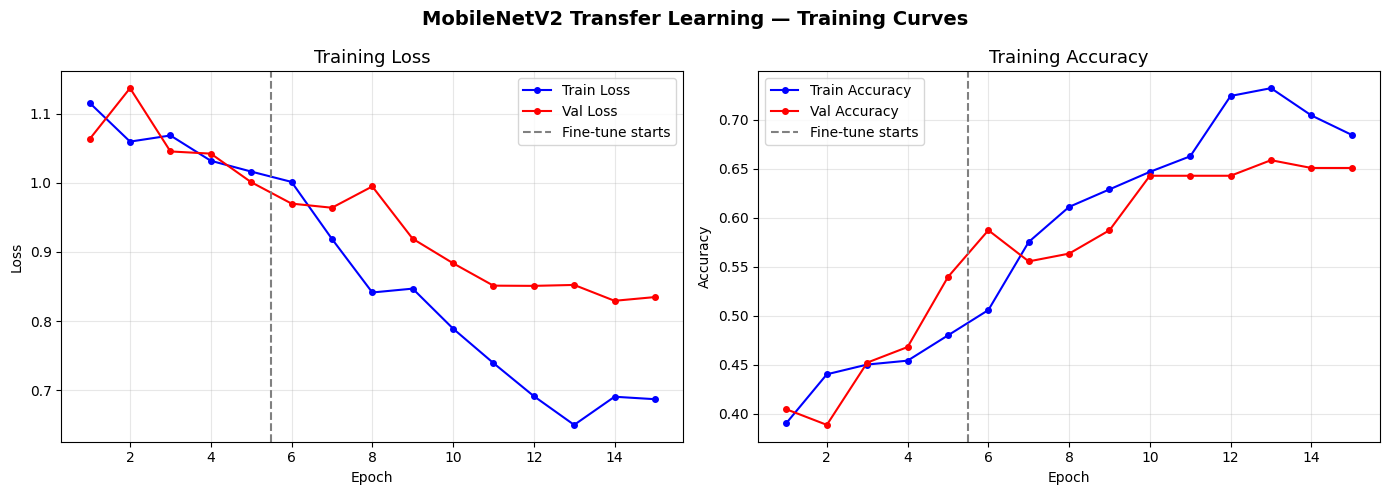

In [11]:
# Training Curves
def plot_history(h1, h2, e1, e2):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs_p1 = range(1, e1 + 1)
    epochs_p2 = range(e1 + 1, e1 + e2 + 1)

    for ax, metric, title in zip(axes,
                                 [('train_loss','val_loss'),('train_acc','val_acc')],
                                 ['Loss','Accuracy']):
        tr_key, vl_key = metric
        full_tr = h1[tr_key] + h2[tr_key]
        full_vl = h1[vl_key] + h2[vl_key]
        all_ep  = list(epochs_p1) + list(epochs_p2)

        ax.plot(all_ep, full_tr, 'b-o', markersize=4, label=f'Train {title}')
        ax.plot(all_ep, full_vl, 'r-o', markersize=4, label=f'Val {title}')
        ax.axvline(e1 + 0.5, color='gray', linestyle='--', label='Fine-tune starts')
        ax.set_xlabel('Epoch'); ax.set_ylabel(title)
        ax.set_title(f'Training {title}', fontsize=13)
        ax.legend(); ax.grid(True, alpha=0.3)

    plt.suptitle('MobileNetV2 Transfer Learning — Training Curves', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

plot_history(history_phase1, history_phase2, EPOCHS_FROZEN, EPOCHS_FINETUNE)


In [12]:
# ── 11. Final Evaluation on Validation Set ──────────────────────────────────
criterion  = nn.CrossEntropyLoss()
val_loss, val_acc, y_pred, y_true = eval_epoch(model, val_loader, criterion)

print(f"Final Validation Loss    : {val_loss:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}  ({val_acc*100:.2f} %)")
print("\n" + "="*55)
print("Classification Report")
print("="*55)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Final Validation Loss    : 0.8522
Final Validation Accuracy: 0.6587  (65.87 %)

Classification Report
              precision    recall  f1-score   support

          CS       0.62      0.90      0.74        42
           D       0.67      0.48      0.56        42
          DD       0.71      0.60      0.65        42

    accuracy                           0.66       126
   macro avg       0.67      0.66      0.65       126
weighted avg       0.67      0.66      0.65       126



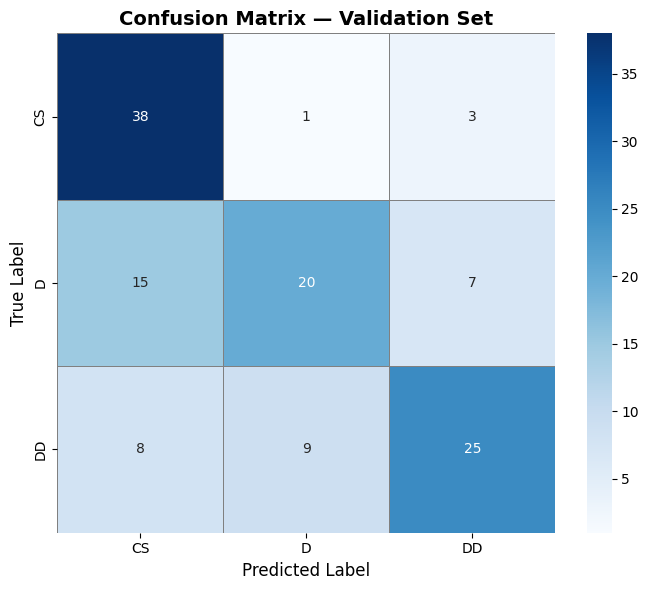

    CS  accuracy: 0.9048
     D  accuracy: 0.4762
    DD  accuracy: 0.5952


In [13]:
# ── 12. Confusion Matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='gray', ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('Confusion Matrix — Validation Set', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Per-class accuracy
for i, cls in enumerate(CLASS_NAMES):
    cls_acc = cm[i, i] / cm[i].sum()
    print(f"  {cls:>4s}  accuracy: {cls_acc:.4f}")


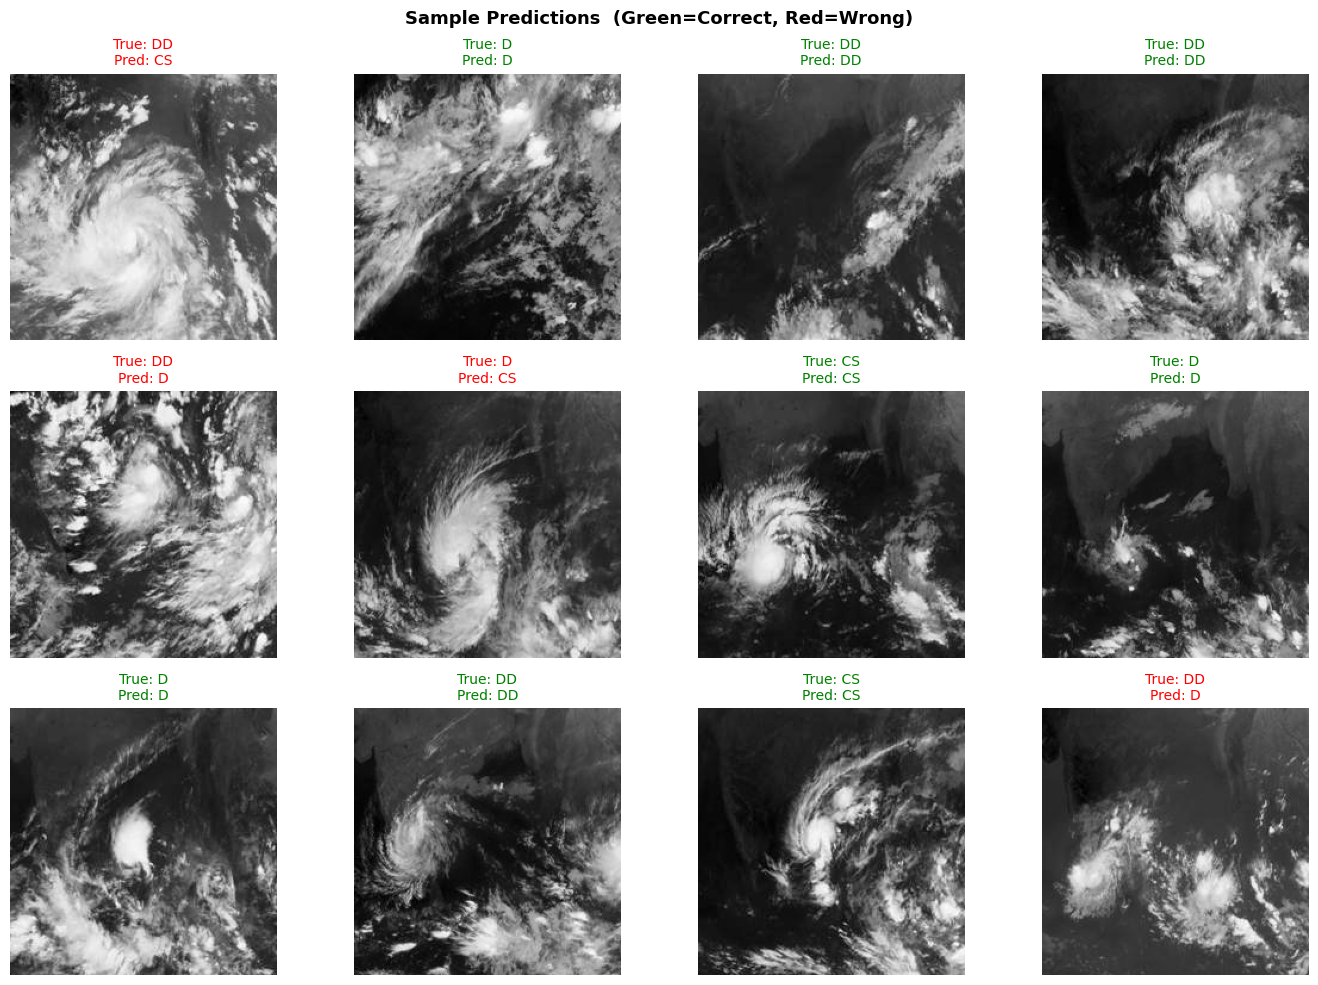

In [14]:
# Sample Predictions Visualization
def show_predictions(model, loader, class_names, n=12):
    model.eval()
    imgs_shown, true_labels, pred_labels = [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            out   = model(imgs.to(DEVICE))
            preds = torch.argmax(out, 1).cpu()
            imgs_shown.extend(imgs[:4])
            true_labels.extend(labels[:4].numpy())
            pred_labels.extend(preds[:4].numpy())
            if len(imgs_shown) >= n:
                break

    inv_norm = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std =[1/0.229,       1/0.224,       1/0.225])

    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    for idx, ax in enumerate(axes.flat):
        if idx >= len(imgs_shown): break
        img = inv_norm(imgs_shown[idx]).clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img[:, :, 0], cmap='gray')   # show first channel (grayscale)
        true_c = class_names[true_labels[idx]]
        pred_c = class_names[pred_labels[idx]]
        color  = 'green' if true_c == pred_c else 'red'
        ax.set_title(f"True: {true_c}\nPred: {pred_c}", color=color, fontsize=10)
        ax.axis('off')
    plt.suptitle('Sample Predictions  (Green=Correct, Red=Wrong)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

show_predictions(model, val_loader, CLASS_NAMES)

In [16]:
# Save the Trained Model
SAVE_PATH = 'mobilenetv2_3class.pth'
torch.save({
    'model_state_dict' : model.state_dict(),
    'class_names'      : CLASS_NAMES,
    'val_accuracy'     : val_acc,
    'img_size'         : IMG_SIZE,
}, SAVE_PATH)

print(f"Model saved → {SAVE_PATH}")
print(f"Final Val Accuracy: {val_acc*100:.2f} %")


Model saved → mobilenetv2_3class.pth
Final Val Accuracy: 65.87 %


Ground truth: CS
Predicted class : CS
Probabilities   : {'CS': '0.403', 'D': '0.309', 'DD': '0.289'}


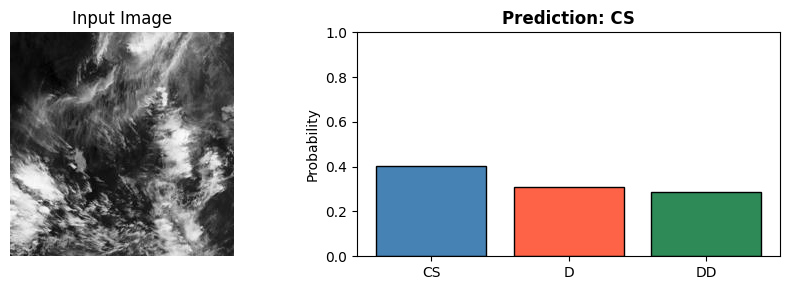

In [17]:
# Single-Image Inference Utility
from PIL import Image as PILImage

def predict_image(img_path, model, class_names, device=DEVICE):
    """Predict the class of a single image."""
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    img    = PILImage.open(img_path).convert('L')
    tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
        pred   = np.argmax(probs)

    print(f"Predicted class : {class_names[pred]}")
    print("Probabilities   :", {c: f'{p:.3f}' for c, p in zip(class_names, probs)})

    fig, axes = plt.subplots(1, 2, figsize=(9, 3))
    axes[0].imshow(PILImage.open(img_path), cmap='gray')
    axes[0].set_title(f'Input Image'); axes[0].axis('off')
    axes[1].bar(class_names, probs, color=['steelblue','tomato','seagreen'], edgecolor='black')
    axes[1].set_ylim(0, 1); axes[1].set_ylabel('Probability')
    axes[1].set_title(f'Prediction: {class_names[pred]}', fontweight='bold')
    plt.tight_layout(); plt.show()

# Demo: predict on a random validation image
import random as rnd
sample_path, sample_label = rnd.choice(full_dataset.samples)
print(f"Ground truth: {CLASS_NAMES[sample_label]}")
predict_image(sample_path, model, CLASS_NAMES)
